# 01 - Hotel Booking Data Audit

**CSE437: Data Science | Group 15**

**Completed here:** raw-file validation, schema, missingness, repeated records, guest and ADR checks, and direct outcome-leakage evidence. **Still pending:** final cleaning, fixed development/test assignments, development-only relationship analysis, and all modeling.

This is a descriptive quality audit of the original file. Full-file class counts and diagnostic outlier thresholds are not held-out model results or fitted preprocessing rules. No rows are removed, values imputed, or models trained. Refer to the repository README for the unchanged research questions.

## Before modeling

The planned substantive focus is lead time, deposit type, and previous cancellation history. Record hypotheses and freeze the validation/metric choices before modeling. Analyze predictor-outcome relationships on development data after the split is fixed.


**Execution record:** These cells were executed sequentially in a fresh Python process using an IPython shell, with their actual outputs captured below. This environment could not launch a separate Jupyter kernel. A normal fresh-kernel Jupyter run remains to be checked before final submission.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform
import sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display, Image

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data' / 'raw').is_dir() and (p / 'notebooks').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open the notebook from the repository or its notebooks directory.')
RAW_PATH = ROOT / 'data' / 'raw' / 'hotel_bookings.csv'
if not RAW_PATH.is_file():
    raise FileNotFoundError('Place the original hotel_bookings.csv in data/raw/. See data/README.md.')
pd.set_option('display.max_rows', 40)
versions = {'python': platform.python_version(), 'pandas': pd.__version__,
            'numpy': np.__version__, 'matplotlib': matplotlib.__version__}
display(pd.Series(versions, name='Audit runtime').to_frame())


,Audit runtime
python,3.12.13
pandas,2.2.3
numpy,2.3.5
matplotlib,3.10.8


## 1. Verify the input and schema

The SHA-256 value identifies the exact uploaded file. A changed source version requires a fresh audit. This notebook never writes to the raw input.


In [2]:
EXPECTED_SHA256 = '7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06'
raw_bytes = RAW_PATH.read_bytes()
source_sha = hashlib.sha256(raw_bytes).hexdigest()
assert source_sha == EXPECTED_SHA256, 'Input differs from the audited source; review and re-audit.'
raw = pd.read_csv(RAW_PATH)
assert raw.shape == (119390, 32), 'Unexpected dimensions.'
assert raw['is_canceled'].notna().all()
assert set(raw['is_canceled'].unique()) == {0, 1}, 'Unexpected target coding.'
file_record = {'filename': RAW_PATH.name, 'bytes': len(raw_bytes),
               'decimal_MB': len(raw_bytes) / 1_000_000,
               'MiB': len(raw_bytes) / 1024**2,
               'rows': len(raw), 'columns': raw.shape[1], 'sha256': source_sha}
display(pd.Series(file_record, name='Verified input').to_frame())
schema = pd.DataFrame({'dtype': raw.dtypes.astype(str),
                       'non_null_count': raw.notna().sum(),
                       'distinct_non_null_values': raw.nunique()})
display(schema)


,Verified input
filename,hotel_bookings.csv
bytes,16855599
decimal_MB,16.855599
MiB,16.074752
rows,119390
columns,32
sha256,7c2ae42a7353905ea136e5c2287f17c92c5435826598bf...


,dtype,non_null_count,distinct_non_null_values
hotel,object,119390,2
is_canceled,int64,119390,2
lead_time,int64,119390,479
arrival_date_year,int64,119390,3
arrival_date_month,object,119390,12
arrival_date_week_number,int64,119390,53
arrival_date_day_of_month,int64,119390,31
stays_in_weekend_nights,int64,119390,17
stays_in_week_nights,int64,119390,35
adults,int64,119390,14


## 2. Coverage and target audit

These are raw-file composition checks, not estimates of future model performance. Construct arrival dates using an explicit month mapping rather than alphabetical month order.


In [3]:
month_names = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_map = {name: i + 1 for i, name in enumerate(month_names)}
arrival = pd.to_datetime(dict(year=raw['arrival_date_year'],
                             month=raw['arrival_date_month'].map(month_map),
                             day=raw['arrival_date_day_of_month']), errors='coerce')
status_date = pd.to_datetime(raw['reservation_status_date'], errors='coerce')
coverage = {'arrival_start': str(arrival.min().date()),
            'arrival_end': str(arrival.max().date()),
            'invalid_arrival_dates': int(arrival.isna().sum()),
            'invalid_status_dates': int(status_date.isna().sum())}
display(pd.Series(coverage, name='Date coverage').to_frame())
display(raw['hotel'].value_counts().rename('bookings').to_frame())
target_counts = raw['is_canceled'].value_counts().reindex([0, 1])
target_table = pd.DataFrame({'outcome': ['Not canceled', 'Canceled'],
                             'count': target_counts.to_numpy(),
                             'percent': target_counts.to_numpy() / len(raw) * 100})
display(target_table.round({'percent': 4}))


,Date coverage
arrival_start,2015-07-01
arrival_end,2017-08-31
invalid_arrival_dates,0
invalid_status_dates,0


,bookings
hotel,
City Hotel,79330
Resort Hotel,40060


,outcome,count,percent
0,Not canceled,75166,62.9584
1,Canceled,44224,37.0416


## 3. Missingness and identifier semantics

Count parsed nulls before assigning meaning. Agency and company numbers are category identifiers, even though CSV parsing gives them floating-point dtypes. Original dataset documentation describes NULL agency/company codes as not applicable; verify this interpretation for source versions rather than treating every blank as an unknown value. Unknown child counts must not silently become zero guests.

Source: Antonio, de Almeida, and Nunes, *Hotel booking demand datasets*, https://doi.org/10.1016/j.dib.2018.11.126 (https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/).


In [4]:
missing = pd.DataFrame({'null_count': raw.isna().sum()})
missing['percent'] = missing['null_count'] / len(raw) * 100
missing = missing.loc[missing['null_count'].gt(0)].sort_values('null_count', ascending=False)
display(missing.round({'percent': 4}))
display(pd.DataFrame({'distinct_non_null_codes': [raw['agent'].nunique(), raw['company'].nunique()]},
                     index=['agent', 'company']))


,null_count,percent
company,112593,94.3069
agent,16340,13.6862
country,488,0.4087
children,4,0.0034


,distinct_non_null_codes
agent,333
company,352


## 4. Repeated records

Report both additional copies after the first occurrence and all records participating in repeated groups. Without a unique booking identifier, identical rows are not proof of accidental duplication. Record the later retain/remove decision and avoid placing identical retained records in different validation partitions.


In [5]:
duplicate_extra = int(raw.duplicated().sum())
duplicate_all = int(raw.duplicated(keep=False).sum())
duplicate_audit = {'additional_exact_copies': duplicate_extra,
                   'additional_copy_percent': duplicate_extra / len(raw) * 100,
                   'all_rows_in_repeated_groups': duplicate_all,
                   'distinct_full_rows': int(len(raw.drop_duplicates()))}
display(pd.Series(duplicate_audit, name='Full-row repetition audit').to_frame())


,Full-row repetition audit
additional_exact_copies,31994.000000
additional_copy_percent,26.797889
all_rows_in_repeated_groups,40165.000000
distinct_full_rows,87396.000000


## 5. Guest counts, stay lengths, and category checks

Using `min_count=3` preserves an unknown total when any of adults, children, or babies is missing. A booking with zero adults is not necessarily a booking with zero total guests. Zero-night stays and overlapping flags require interpretation; do not add overlapping issue counts or automatically remove every flagged row.


In [6]:
guest_columns = ['adults', 'children', 'babies']
total_guests = raw[guest_columns].sum(axis=1, min_count=3)
total_nights = raw['stays_in_weekend_nights'] + raw['stays_in_week_nights']
zero_guest = total_guests.eq(0)
zero_night = total_nights.eq(0)
guest_audit = {'zero_complete_guest_total': int(zero_guest.sum()),
               'unknown_guest_total': int(total_guests.isna().sum()),
               'zero_adults': int(raw['adults'].eq(0).sum()),
               'zero_adults_but_known_positive_total': int((raw['adults'].eq(0) & total_guests.gt(0)).sum()),
               'negative_guest_count_rows': int(raw[guest_columns].lt(0).any(axis=1).sum()),
               'zero_night_stays': int(zero_night.sum()),
               'zero_guest_and_zero_night_overlap': int((zero_guest & zero_night).sum())}
display(pd.Series(guest_audit, name='Guest and stay checks').to_frame())
undefined_counts = {c: int(raw[c].eq('Undefined').sum())
                    for c in ['market_segment', 'distribution_channel', 'meal']}
display(pd.Series(undefined_counts, name='Explicit Undefined categories').to_frame())


,Guest and stay checks
zero_complete_guest_total,180
unknown_guest_total,4
zero_adults,403
zero_adults_but_known_positive_total,223
negative_guest_count_rows,0
zero_night_stays,715
zero_guest_and_zero_night_overlap,70


,Explicit Undefined categories
market_segment,2
distribution_channel,5
meal,1169


## 6. ADR diagnostics

The full-file IQR rule here is diagnostic only. It is not a cleaning threshold to reuse in cross-validation. Domain checks are separate: a negative ADR can escape the statistical fence. Zero and high rates may have legitimate explanations; inspect them before treatment. Any data-dependent clipping or imputation must later be fitted inside training folds.


In [7]:
adr = raw['adr']
q1, q3 = adr.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
iqr_flag = adr.lt(lower) | adr.gt(upper)
adr_audit = {'min': float(adr.min()), 'median': float(adr.median()), 'max': float(adr.max()),
             'q1': float(q1), 'q3': float(q3),
             'diagnostic_iqr_lower': float(lower), 'diagnostic_iqr_upper': float(upper),
             'iqr_flagged': int(iqr_flag.sum()), 'negative': int(adr.lt(0).sum()),
             'zero': int(adr.eq(0).sum()), 'above_1000': int(adr.gt(1000).sum()),
             'negative_not_flagged_by_iqr': int((adr.lt(0) & ~iqr_flag).sum())}
display(pd.Series(adr_audit, name='ADR audit').to_frame())
display(adr.nlargest(5).reset_index(drop=True).rename('Largest ADR values').to_frame())


,ADR audit
min,-6.380
median,94.575
max,5400.000
q1,69.290
q3,126.000
diagnostic_iqr_lower,-15.775
diagnostic_iqr_upper,211.065
iqr_flagged,3793.000
negative,1.000
zero,1959.000


,Largest ADR values
0,5400.0
1,510.0
2,508.0
3,451.5
4,450.0


## 7. Direct outcome-leakage check

Reservation status is audited only to demonstrate why it cannot be a predictor. Remove both status columns from all future predictor paths, including selection/reduction. The remaining columns are candidates, not a certification that every value was available at the intended prediction time. Review booking changes, room assignment, waiting-list history, and other potentially updated fields separately.


In [8]:
status_cross = pd.crosstab(raw['reservation_status'], raw['is_canceled'])
display(status_cross)
status_matches_target = bool(raw['reservation_status'].ne('Check-Out').astype(int).eq(raw['is_canceled']).all())
EXCLUDED_OUTCOME_COLUMNS = ['reservation_status', 'reservation_status_date']
candidate_X = raw.drop(columns=['is_canceled', *EXCLUDED_OUTCOME_COLUMNS])
assert not set(['is_canceled', *EXCLUDED_OUTCOME_COLUMNS]) & set(candidate_X.columns)
print('Status reproduces all observed target labels:', status_matches_target)
print('Remaining candidate predictors before further availability review:', candidate_X.shape[1])


Status reproduces all observed target labels: True
Remaining candidate predictors before further availability review: 29


is_canceled,0,1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207


## 8. Save an audit figure

This figure summarizes data quality and raw class composition. It is not a performance chart.


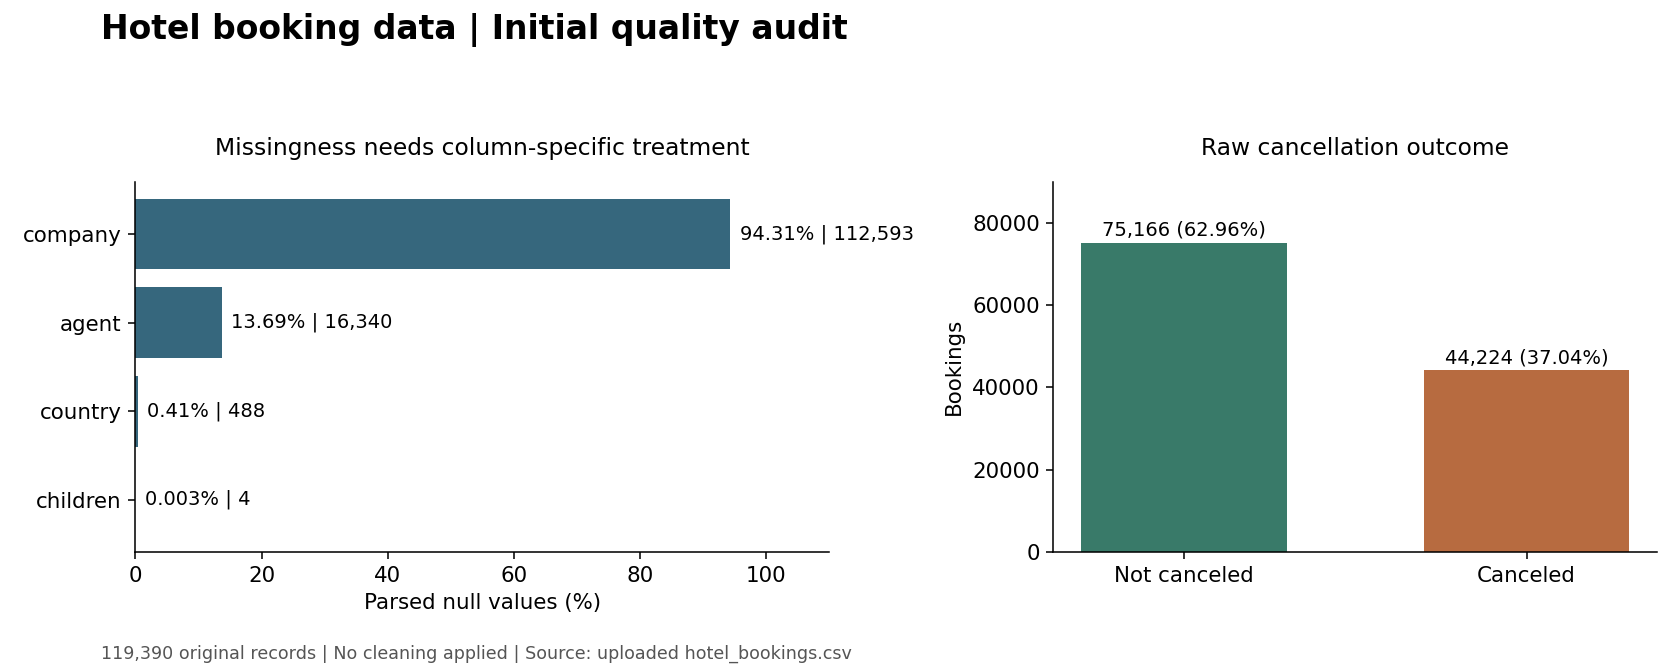

In [9]:
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={'width_ratios': [1.15, 1]})
axes[0].barh(missing.index, missing['percent'], color='#36677D')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 110)
axes[0].set_xlabel('Parsed null values (%)')
axes[0].set_title('Missingness needs column-specific treatment', fontsize=12, pad=14)
for i, (_, row) in enumerate(missing.iterrows()):
    precision = 3 if row['percent'] < 0.01 else 2
    label = f"{row['percent']:.{precision}f}% | {int(row['null_count']):,}"
    axes[0].text(row['percent'] + 1.5, i, label, va='center', fontsize=10)
bars = axes[1].bar(target_table['outcome'], target_table['count'], color=['#397A69', '#B76B40'], width=0.6)
axes[1].set_ylim(0, 90000)
axes[1].set_ylabel('Bookings')
axes[1].set_title('Raw cancellation outcome', fontsize=12, pad=14)
for bar, (_, row) in zip(bars, target_table.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, row['count'] + 1700,
                 f"{int(row['count']):,} ({row['percent']:.2f}%)", ha='center', fontsize=10)
fig.suptitle('Hotel booking data | Initial quality audit', x=0.06, ha='left', fontsize=17, weight='bold')
fig.text(0.06, 0.02, '119,390 original records | No cleaning applied | Source: uploaded hotel_bookings.csv',
         color='#555555', fontsize=9)
fig.tight_layout(rect=(0, 0.05, 1, 0.92))
figure_path = ROOT / 'figures' / '01_data_quality_audit.png'
fig.savefig(figure_path, dpi=140, facecolor='white')
plt.close(fig)
display(Image(filename=str(figure_path)))


## 9. Save measured evidence and verify source preservation

The machine-readable audit record contains measured counts, source identity, and runtime versions. No cleaned dataset is produced at this stage.


In [10]:
audit = {'stage': 'raw_data_audit_only',
         'audit_time_utc': datetime.now(timezone.utc).isoformat(),
         'source': file_record, 'coverage': coverage, 'runtime': versions,
         'hotel_counts': {str(k): int(v) for k, v in raw['hotel'].value_counts().items()},
         'target_counts': {str(k): int(v) for k, v in target_counts.items()},
         'cancellation_percent': float(raw['is_canceled'].mean() * 100),
         'missingness': {c: {'count': int(r['null_count']), 'percent': float(r['percent'])}
                        for c, r in missing.iterrows()},
         'duplicates': duplicate_audit, 'guest_checks': guest_audit, 'adr': adr_audit,
         'undefined_categories': undefined_counts,
         'status_matches_target': status_matches_target,
         'candidate_predictor_count': int(candidate_X.shape[1]),
         'cleaning_applied': False, 'modeling_started': False}
audit_path = ROOT / 'data' / 'audit_summary.json'
audit_path.write_text(json.dumps(audit, indent=2) + '\n', encoding='utf-8')
assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest() == EXPECTED_SHA256
assert raw.shape == (119390, 32)
print('Saved data/audit_summary.json and figures/01_data_quality_audit.png')
print('Original CSV checksum unchanged. No rows or values were modified.')


Saved data/audit_summary.json and figures/01_data_quality_audit.png
Original CSV checksum unchanged. No rows or values were modified.


## 10. Findings and next implementation decisions

- The file has the expected 119,390 records, 32 columns, and a valid binary target. Cancellation prevalence is approximately 37.04%.
- Company and agent null shares differ substantially. Do not discard both based on the same missingness assumption; confirm null semantics and use categorical handling.
- There are 31,994 additional copies of full rows. Document their meaning and a partition-safe retain/remove policy before modeling.
- There are 180 known zero-total-guest records; another four totals are unknown. Zero-adult filtering would also affect 223 records with positive guest totals.
- ADR requires separate statistical and domain checks. The negative value is not caught by the raw-data IQR fence; the maximum of 5,400 is far above the next largest value of 510.
- Reservation status directly encodes the label. Both status columns must remain outside predictors.

Next: resolve data eligibility and repeat-record policy, record preprocessing rules, freeze development/test assignments, and conduct predictor-outcome EDA on development data. Preserve the original source and fit learned transforms only within training folds. No predictive accuracy or model ranking has been established.

## References and assistance

- Dataset source specified for this project: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
- Antonio, N., de Almeida, A., and Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41-49. https://doi.org/10.1016/j.dib.2018.11.126
- Original data documentation: https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/

Exact terms for the downloaded Kaggle version still need to be recorded. The observation-time description in the original publication is relative to the day before arrival, so operational booking-time availability requires additional checking.

OpenAI ChatGPT/Codex assisted with audit code, execution, figures, and interpretation. Group members should review these findings and record their actual work.
